# Data Understanding

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud

## 1.Load the dataset

In [2]:
data=pd.read_csv('../dataset/IMDB Dataset.csv')

### view the data

In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [5]:
data.shape

(50000, 2)

## 2.Understand the dataset

### Check missing values

In [6]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

##### There is no missisng values in the moview review datasets

### CHECK DUPLICATES

In [7]:
data.duplicated().sum()

np.int64(418)

In [8]:
print("duplicate reviews:",data['review'].duplicated().sum())

duplicate reviews: 418


In [9]:
duplicates=data[data['review'].duplicated(keep=False)]
duplicates.head(20)

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
480,From director Barbet Schroder (Reversal of For...,negative
513,"The story and the show were good, but it was r...",negative
636,I rented this thinking it would be pretty good...,negative
638,This movie has everything typical horror movie...,positive
701,I Enjoyed Watching This Well Acted Movie Very ...,positive


### Check datatypes

In [10]:
data.dtypes

review       str
sentiment    str
dtype: object

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [12]:
data.describe(include="all")

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


### Check sentiment values

In [13]:
data['sentiment'].unique()

<StringArray>
['positive', 'negative']
Length: 2, dtype: str

In [14]:
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

#### Both positive and negative are equal split in the daatset

### 3.Check Sentiment Distribution

In [15]:
sentiment_counts = data["sentiment"].value_counts()
print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [17]:
sentiment_percentage=(data["sentiment"].value_counts(normalize=True) * 100)
print(sentiment_percentage)

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


### 4.Analyze Review Length

#### creating a new column for review_length

In [18]:
data["review_length"] = data["review"].astype(str).apply(len)

In [19]:
data[["review","review_length"]].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926
3,Basically there's a family where a little boy ...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317


#### Number of word in each review

In [20]:
data['word_count']=(data['review'].astype(str).apply(lambda x: len(x.split())))

In [21]:
data[["review","word_count"]].head()

,review,word_count
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


In [22]:
data.columns

Index(['review', 'sentiment', 'review_length', 'word_count'], dtype='str')

### 5.Review length statistics

In [23]:
print(data["review_length"].describe())

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


In [24]:
print(data["word_count"].describe())

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


### 7.Find Reviews Word Frequency

In [30]:
all_reviews = " ".join(data["review"].astype(str))

In [34]:
words=all_reviews.lower().split()

In [35]:
word_counts=Counter(words)

In [36]:
word_counts.most_common(20)

[('the', 638861),
 ('a', 316615),
 ('and', 313637),
 ('of', 286661),
 ('to', 264573),
 ('is', 204876),
 ('in', 179807),
 ('i', 141587),
 ('this', 138483),
 ('that', 130140),
 ('it', 129614),
 ('/><br', 100974),
 ('was', 93258),
 ('as', 88242),
 ('with', 84590),
 ('for', 84510),
 ('but', 77864),
 ('on', 62890),
 ('movie', 61492),
 ('are', 57009)]

### Visualizations

#### 1.Sentiment Distribution

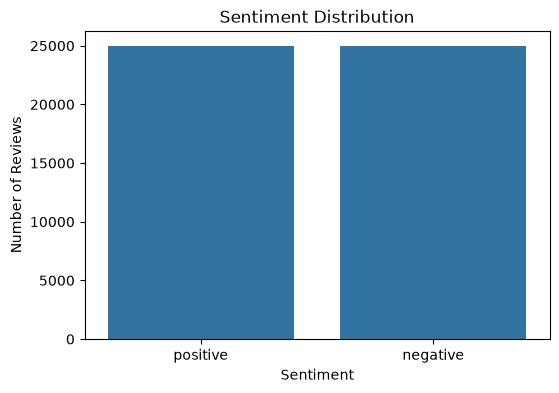

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

#### 2. Review Length Distribution

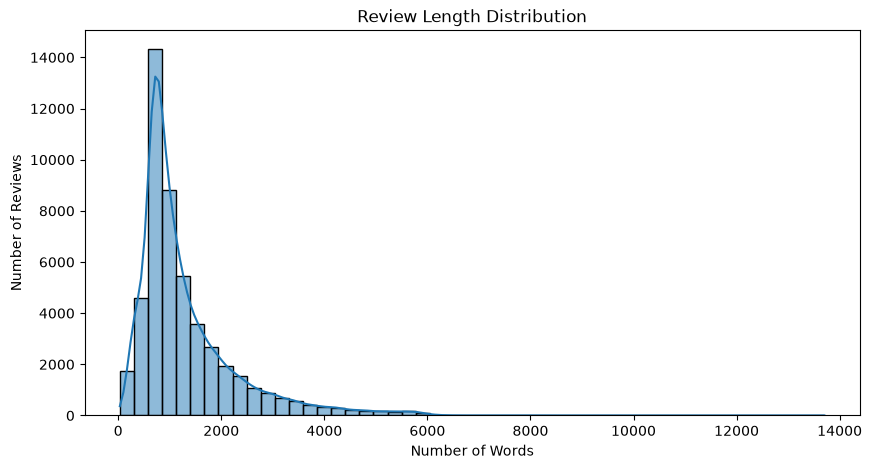

In [42]:
plt.figure(figsize=(10,5))
sns.histplot(data["review_length"], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

#### 3.Word Frequency

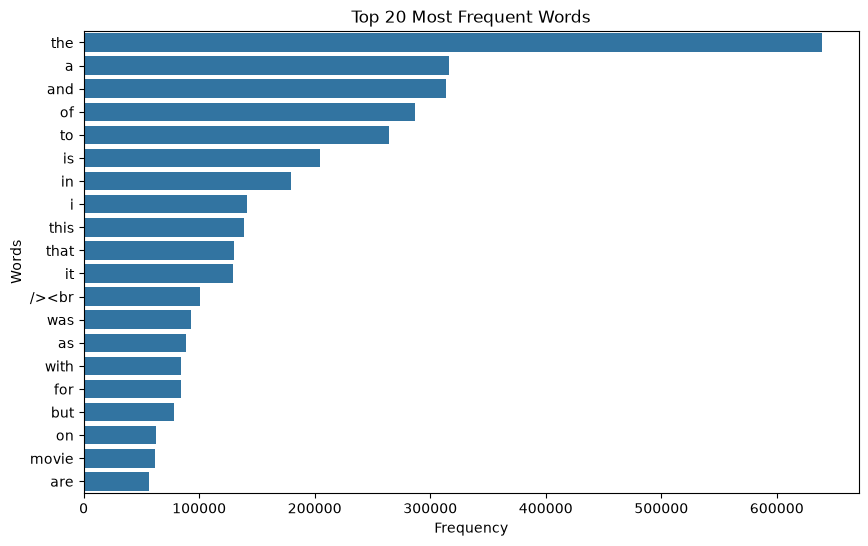

In [44]:
top_words = word_counts.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

#### 4.Word Cloud

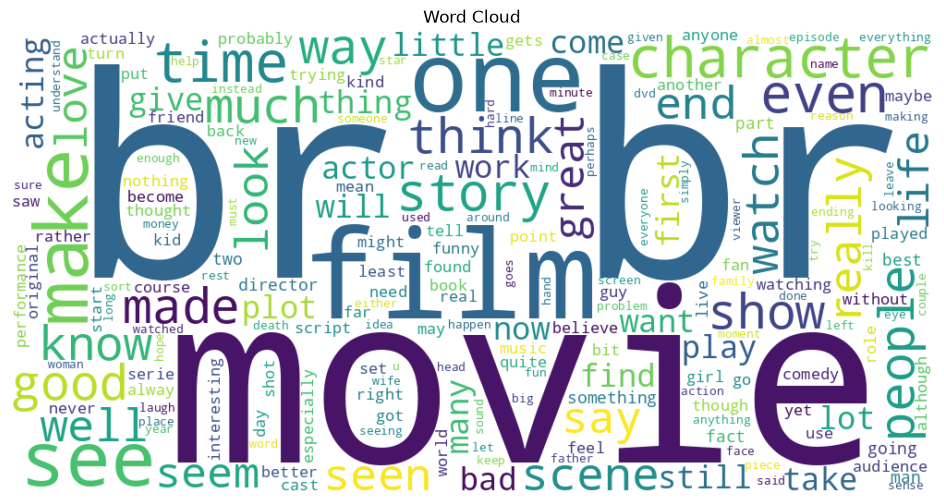

In [45]:
wordcloud = WordCloud(width=1000,height=500,background_color="white").generate(all_reviews)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()